# Getting started with BI500 data in echopype

This notebook follows the same general flow as the echopype getting-started example, but adapts it to the BI500 data model.

BI500 differs from raw EK60/EK80 data because the `-Data` file already contains calibrated acoustic products generated by the EK500/BI500 system. Consequently, `open_raw` returns two objects:

```python
echodata, ds_cal = ep.open_raw(...)
```

- `echodata` contains metadata, navigation, provenance, and BI500 acquisition information.
- `ds_cal` contains the calibrated pelagic, bottom, and single-target products.

The single-target variables use the same SONAR-netCDF-style names as the single-target detection workflow, including `single_target`, `single_target_range`, `uncompensated_TS`, and `compensated_TS`.


## Imports


In [1]:
from pathlib import Path

import echopype as ep
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr


## Locate the BI500 file set

A BI500 recording is represented by a set of files sharing the same prefix, including `-Data`, `-Info`, and `-Ping`. This example expects the test files in:

```text
echopype-examples/notebooks/notebooks/bi500_test_data/
```


In [2]:
notebook_dir = Path.cwd()
bi500_dir = notebook_dir / "example_data" / "bi500_test_data"

if not bi500_dir.is_dir():
    raise FileNotFoundError(
        "BI500 test-data directory not found. Expected: "
        f"{bi500_dir}"
    )

bi500_path = bi500_dir


### Inspect and validate the file set


In [3]:
bi500_files = sorted(path.name for path in bi500_dir.iterdir())
bi500_files


['N031-S445-S2000008-F011990-T01-D20000921-T034142-Data',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Info',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Ping',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Snap',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Vlog',
 'N031-S445-S2000008-F011990-T01-D20000921-T034142-Work']

In [4]:
required_suffixes = {"-Data", "-Info", "-Ping"}

available_suffixes = {
    suffix
    for path in bi500_dir.iterdir()
    for suffix in required_suffixes
    if path.name.endswith(suffix)
}

missing_suffixes = required_suffixes - available_suffixes
if missing_suffixes:
    raise FileNotFoundError(
        f"Missing required BI500 files: {sorted(missing_suffixes)}"
    )


## Open the BI500 data

Unlike the standard raw-data workflow, BI500 returns both an `EchoData` object and a calibrated `xarray.Dataset`.


In [5]:
echodata, ds_cal = ep.open_raw(
    raw_file=str(bi500_path),
    sonar_model="BI500",
)


In [6]:
type(echodata), type(ds_cal)


(echopype.echodata.echodata.EchoData, xarray.core.dataset.Dataset)

## Inspect the `EchoData` object

The `EchoData` object holds metadata and ancillary information rather than the calibrated BI500 arrays.


In [7]:
echodata


<EchoData: standardized raw data from Internal Memory>
Top-level: contains metadata about the SONAR-netCDF4 file format.
├── Environment: contains information relevant to acoustic propagation through water.
├── Platform: contains information about the platform on which the sonar is installed.
├── Provenance: contains metadata about how the SONAR-netCDF4 version of the data were obtained.
├── Sonar: contains sonar system metadata and sonar beam groups.
│   └── Beam_group1: Contains BI500 channel, ping, and echogram geometry metadata.
└── Vendor_specific: contains vendor-specific information about the sonar and the data.

### Platform information

The `Platform` group contains navigation, vessel-log, and bottom-depth information reconstructed from the BI500 `-Ping` and `-Vlog` files.


In [8]:
echodata["Platform"]


<xarray.Dataset> Size: 173kB
Dimensions:                   (ping_time: 3323, ping_time_vlog: 1000)
Coordinates:
  * ping_time                 (ping_time) datetime64[ns] 27kB 2000-09-21T09:2...
  * ping_time_vlog            (ping_time_vlog) datetime64[ns] 8kB 2000-09-21T...
Data variables:
    latitude                  (ping_time) float64 27kB 41.66 41.66 ... 41.61
    latitude_vlog             (ping_time_vlog) float64 8kB 41.66 41.66 ... 41.61
    longitude                 (ping_time) float64 27kB -68.58 -68.58 ... -68.57
    longitude_vlog            (ping_time_vlog) float64 8kB -68.58 ... -68.57
    bottom_depth              (ping_time) float64 27kB 169.2 168.8 ... 141.2
    bottom_depth_vlog         (ping_time_vlog) float64 8kB 169.2 169.2 ... 141.6
    vessel_log_distance       (ping_time) float64 27kB 2.127e+03 ... 2.132e+03
    vessel_log_distance_vlog  (ping_time_vlog) float64 8kB 2.127e+03 ... 2.13...
Attributes:
    platform_name:       
    platform_type:       
    platform_code_ICES:  445

### Sonar and beam information

`Sonar/Beam_group1` contains channel metadata, ping coordinates, and echogram geometry. The calibrated BI500 arrays are intentionally not represented as raw `backscatter_r`.


In [9]:
beam = echodata["Sonar/Beam_group1"]
beam


<xarray.Dataset> Size: 208kB
Dimensions:                     (channel: 1, ping_time: 3323,
                                 ping_time_vlog: 1000, beam_group: 1)
Coordinates:
  * channel                     (channel) object 8B 'BI500-F11990-T01'
  * ping_time                   (ping_time) datetime64[ns] 27kB 2000-09-21T09...
  * ping_time_vlog              (ping_time_vlog) datetime64[ns] 8kB 2000-09-2...
  * beam_group                  (beam_group) <U11 44B 'Beam_group1'
Data variables: (12/13)
    frequency_nominal           (channel) float64 8B 1.199e+04
    transceiver_channel_number  (channel) int64 8B 1
    beam_type                   (channel) int64 8B 0
    echogram_type               (ping_time) int64 27kB 0 0 0 0 0 0 ... 0 0 0 0 0
    echogram_type_vlog          (ping_time_vlog) int64 8kB 0 0 0 0 0 ... 0 0 0 0
    pelagic_upper               (channel, ping_time) float64 27kB 0.0 ... 0.0
    ...                          ...
    pelagic_upper_vlog          (channel, ping_time_vlog) float64 8kB 0.0 ......
    pelagic_lower_vlog          (channel, ping_time_vlog) float64 8kB 500.0 ....
    bottom_upper                (channel, ping_time) float64 27kB 10.0 ... 10.0
    bottom_lower                (channel, ping_time) float64 27kB -5.0 ... -5.0
    bottom_upper_vlog           (channel, ping_time_vlog) float64 8kB 10.0 .....
    bottom_lower_vlog           (channel, ping_time_vlog) float64 8kB -5.0 .....

BI500 files already contain calibrated backscatter products rather than raw power samples. Therefore, the converted EchoData should not expose SONAR-netCDF raw variables such as backscatter_r or backscatter_r_bottom.

In [10]:
assert "backscatter_r" not in beam
assert "backscatter_r_bottom" not in beam


### Vendor-specific information

The `Vendor_specific` group retains BI500 file-level metadata that does not fit directly into standardized groups.


In [11]:
echodata["Vendor_specific"]


<xarray.Dataset> Size: 48B
Dimensions:          ()
Data variables:
    start_latitude   float64 8B 41.66
    start_longitude  float64 8B -68.58
    start_distance   float64 8B 2.127e+03
    stop_latitude    float64 8B 41.61
    stop_longitude   float64 8B -68.57
    stop_distance    float64 8B 2.132e+03

## Inspect the calibrated dataset

`ds_cal` combines two types of products:

- gridded echogram products: `Sv` and `Sv_bottom`;
- event-like single-target products indexed by `single_target`.

The single-target values are not gridded over every ping and range sample. Each entry represents one target detection and is linked to its source ping using `ping_index` and `single_target_ping_time`.


In [12]:
ds_cal


<xarray.Dataset> Size: 27MB
Dimensions:                          (channel: 1, ping_time: 3323,
                                      range_sample: 500,
                                      range_sample_bottom: 150,
                                      single_target: 8724)
Coordinates:
  * channel                          (channel) <U16 64B 'BI500-F11990-T01'
  * ping_time                        (ping_time) datetime64[ns] 27kB 2000-09-...
  * range_sample                     (range_sample) int64 4kB 0 1 2 ... 498 499
  * range_sample_bottom              (range_sample_bottom) int64 1kB 0 1 ... 149
  * single_target                    (single_target) int64 70kB 0 1 ... 8723
Data variables: (12/17)
    Sv                               (channel, ping_time, range_sample) float32 7MB ...
    Sv_bottom                        (channel, ping_time, range_sample_bottom) float32 2MB ...
    frequency_nominal                (channel) float64 8B 1.199e+04
    echo_range                       (channel, ping_time, range_sample) float64 13MB ...
    echo_range_bottom                (channel, ping_time, range_sample_bottom) float64 4MB ...
    pelagic_upper                    (channel, ping_time) float64 27kB 0.0 .....
    ...                               ...
    single_target_ping_time          (single_target) datetime64[ns] 70kB 2000...
    single_target_range              (single_target) float64 70kB 51.6 ... 8.4
    single_target_alongship_angle    (single_target) float64 70kB 0.0 ... 0.0
    single_target_athwartship_angle  (single_target) float64 70kB 0.0 ... 0.0
    uncompensated_TS                 (single_target) float64 70kB -54.17 ... ...
    compensated_TS                   (single_target) float64 70kB -53.99 ... ...
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              The BI500 system generated these calibrated quantit...

### List the single-target variables


In [13]:
target_variables = [
    name
    for name, variable in ds_cal.data_vars.items()
    if "single_target" in variable.dims
]

ds_cal[target_variables]


<xarray.Dataset> Size: 628kB
Dimensions:                          (single_target: 8724)
Coordinates:
  * single_target                    (single_target) int64 70kB 0 1 ... 8723
Data variables:
    single_target_identifier         (single_target) int64 70kB 0 1 ... 8723
    ping_index                       (single_target) int64 70kB 1 1 ... 3322
    single_target_ping_time          (single_target) datetime64[ns] 70kB 2000...
    single_target_range              (single_target) float64 70kB 51.6 ... 8.4
    single_target_alongship_angle    (single_target) float64 70kB 0.0 ... 0.0
    single_target_athwartship_angle  (single_target) float64 70kB 0.0 ... 0.0
    uncompensated_TS                 (single_target) float64 70kB -54.17 ... ...
    compensated_TS                   (single_target) float64 70kB -53.99 ... ...
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              The BI500 system generated these calibrated quantit...

## Inspect physical range and add depth

The calibrated BI500 output follows the regular gridded echopype structure:

- `range_sample` is the zero-based sample index;
- `echo_range` is the reconstructed physical range associated with `Sv`;
- `depth` is added as a separate variable using `add_depth()`.

The current `echo_range` reconstruction assumes that the BI500 upper and lower limits are bin edges.

### TODO: CONFIRM


In [14]:
ds_cal[["Sv", "echo_range", "Sv_bottom", "echo_range_bottom"]]


<xarray.Dataset> Size: 26MB
Dimensions:              (channel: 1, ping_time: 3323, range_sample: 500,
                          range_sample_bottom: 150)
Coordinates:
  * channel              (channel) <U16 64B 'BI500-F11990-T01'
  * ping_time            (ping_time) datetime64[ns] 27kB 2000-09-21T09:29:03 ...
  * range_sample         (range_sample) int64 4kB 0 1 2 3 4 ... 496 497 498 499
  * range_sample_bottom  (range_sample_bottom) int64 1kB 0 1 2 3 ... 147 148 149
Data variables:
    Sv                   (channel, ping_time, range_sample) float32 7MB -235....
    echo_range           (channel, ping_time, range_sample) float64 13MB 0.5 ...
    Sv_bottom            (channel, ping_time, range_sample_bottom) float32 2MB ...
    echo_range_bottom    (channel, ping_time, range_sample_bottom) float64 4MB ...
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              The BI500 system generated these calibrated quantit...

### Add a depth variable

`add_depth()` preserves `range_sample` as the dimension and adds `depth(channel, ping_time, range_sample)` alongside `echo_range`.

The offset below is explicitly user supplied. Replace it with the actual transducer depth/draft for the deployment. It is not inferred from the BI500 files in this example.


In [15]:
transducer_depth = 0.0  # m; replace with the deployment-specific transducer depth

ds_cal = ep.consolidate.add_depth(
    ds_cal,
    echodata,
    depth_offset=transducer_depth,
)

ds_cal[["Sv", "echo_range", "depth"]]


<xarray.Dataset> Size: 33MB
Dimensions:       (channel: 1, ping_time: 3323, range_sample: 500)
Coordinates:
  * channel       (channel) <U16 64B 'BI500-F11990-T01'
  * ping_time     (ping_time) datetime64[ns] 27kB 2000-09-21T09:29:03 ... 200...
  * range_sample  (range_sample) int64 4kB 0 1 2 3 4 5 ... 495 496 497 498 499
Data variables:
    Sv            (channel, ping_time, range_sample) float32 7MB -235.2 ... -...
    echo_range    (channel, ping_time, range_sample) float64 13MB 0.5 ... 499.5
    depth         (channel, ping_time, range_sample) float64 13MB 0.5 ... 499.5
Attributes:
    processing_function:  open_raw
    source_sonar_model:   BI500
    comment:              The BI500 system generated these calibrated quantit...

## Visualizing the calibrated BI500 echogram

The calibrated `Sv` dataset can be displayed directly from `ds_cal`. Here we first plot the echogram against **ping number**, which provides a continuous view of the recorded data without visual gaps caused by interruptions in acquisition.

Text(0, 0.5, 'Range sample')

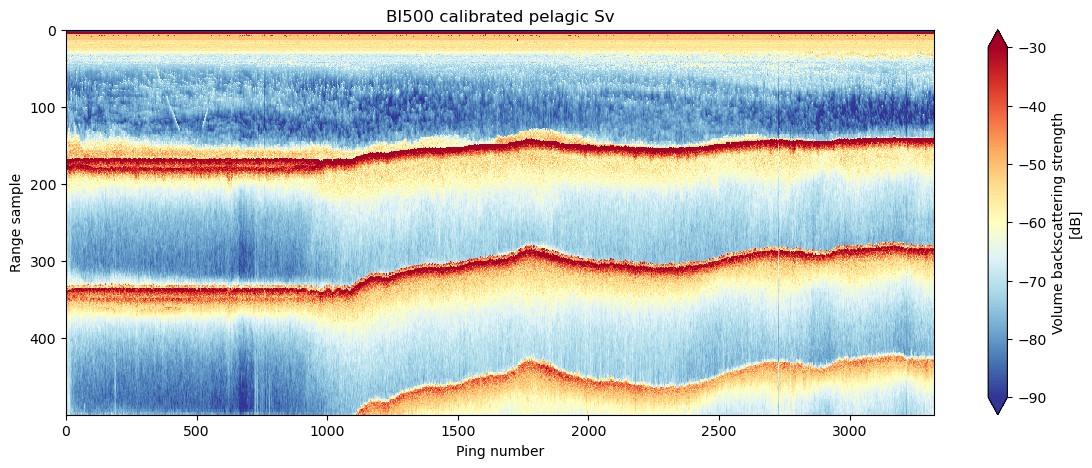

In [16]:
sv_plot = (
    ds_cal["Sv"]
    .isel(channel=0)
    .assign_coords(ping_time=np.arange(ds_cal.sizes["ping_time"]))
)

plot_obj = sv_plot.plot(
    x="ping_time",
    y="range_sample",
    yincrease=False,
    vmin=-90,
    vmax=-30,
    cmap="RdYlBu_r",
    figsize=(14, 5),
)

plot_obj.axes.set_title("BI500 calibrated pelagic Sv")
plot_obj.axes.set_xlabel("Ping number")
plot_obj.axes.set_ylabel("Range sample")

In the next section, we plot the same data against the original **ping timestamps**. This preserves the true acquisition times, but long gaps between recordings are stretched in the visualization, reflecting the actual time elapsed.

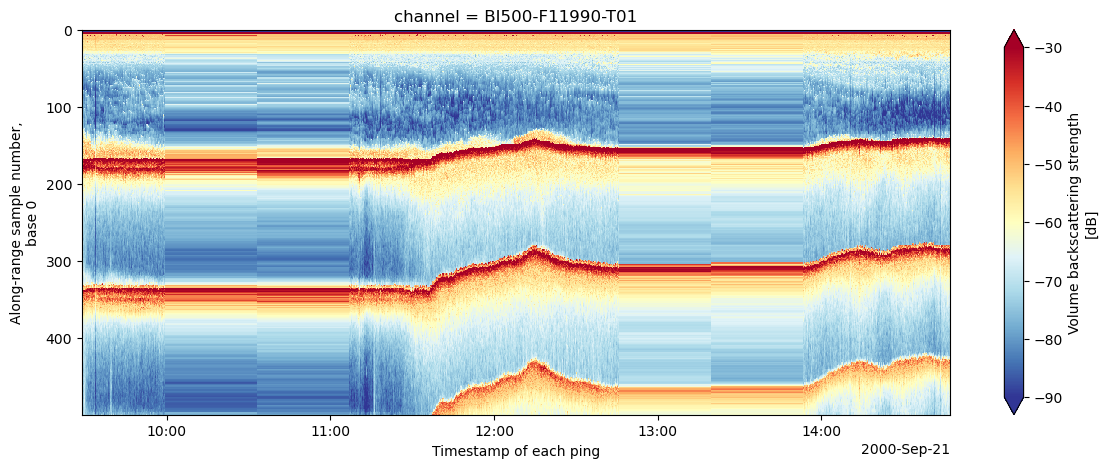

In [17]:
sv_plot = ds_cal["Sv"].isel(channel=0)

plot_obj = sv_plot.plot(
    x="ping_time",
    y="range_sample",
    yincrease=False,
    vmin=-90,
    vmax=-30,
    cmap="RdYlBu_r",
    figsize=(14, 5),
)

## Overlay the single targets stored in the BI500 file

The BI500 file already stores target detections. These are represented as one-dimensional target-level variables rather than as a gridded TS echogram.

Here we overlay their range and compensated TS on the pelagic echogram.


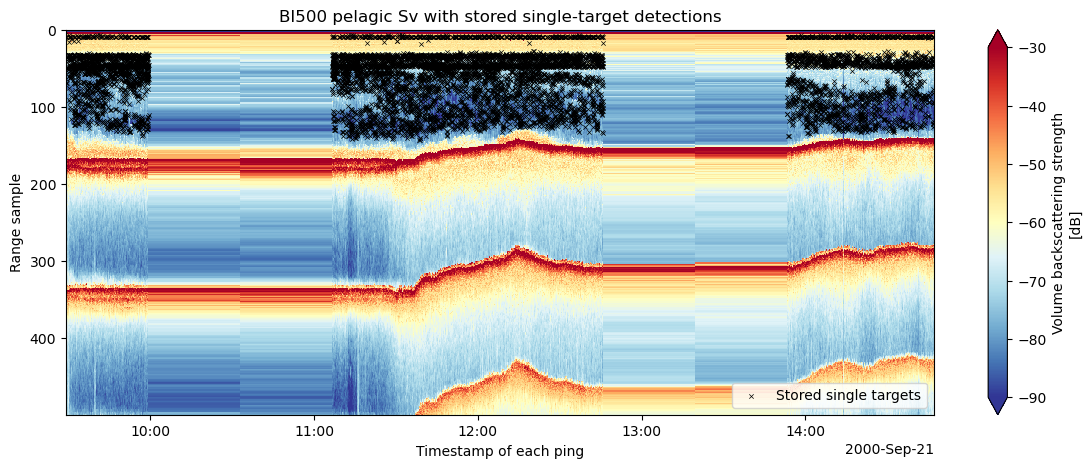

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

ds_cal["Sv"].isel(channel=0).plot(
    ax=ax,
    x="ping_time",
    y="range_sample",
    yincrease=False,
    vmin=-90,
    vmax=-30,
    cmap="RdYlBu_r",
    add_colorbar=True,
)

ax.scatter(
    ds_cal["single_target_ping_time"].values,
    ds_cal["single_target_range"].values,
    marker="x",
    c="black",
    s=10,
    linewidths=0.5,
    label="Stored single targets",
)

ax.set_title("BI500 pelagic Sv with stored single-target detections")
ax.set_ylabel("Range sample")
ax.legend(loc="lower right")

plt.show()

## Compute mean volume backscattering strength (MVBS)

As in the general getting-started workflow, the gridded `Sv` product can be binned in time and depth.

This uses the approximate depth coordinate derived above.


In [19]:
ds_MVBS = ep.commongrid.compute_MVBS(
    ds_cal,
    range_var="echo_range",
    range_bin="1m",
    ping_time_bin="1min",
)

ds_MVBS


<xarray.Dataset> Size: 645kB
Dimensions:            (channel: 1, ping_time: 319, echo_range: 500)
Coordinates:
  * channel            (channel) <U16 64B 'BI500-F11990-T01'
  * ping_time          (ping_time) datetime64[ns] 3kB 2000-09-21T09:29:00 ......
  * echo_range         (echo_range) float64 4kB 0.0 1.0 2.0 ... 498.0 499.0
Data variables:
    Sv                 (channel, ping_time, echo_range) float32 638kB -235.2 ...
    frequency_nominal  (channel) float64 8B 1.199e+04
Attributes:
    processing_software_name:     echopype
    processing_software_version:  0.11.2.dev183+g02b009a05
    processing_time:              2026-08-02T19:38:40+00:00
    processing_function:          commongrid.compute_MVBS

### Plot MVBS


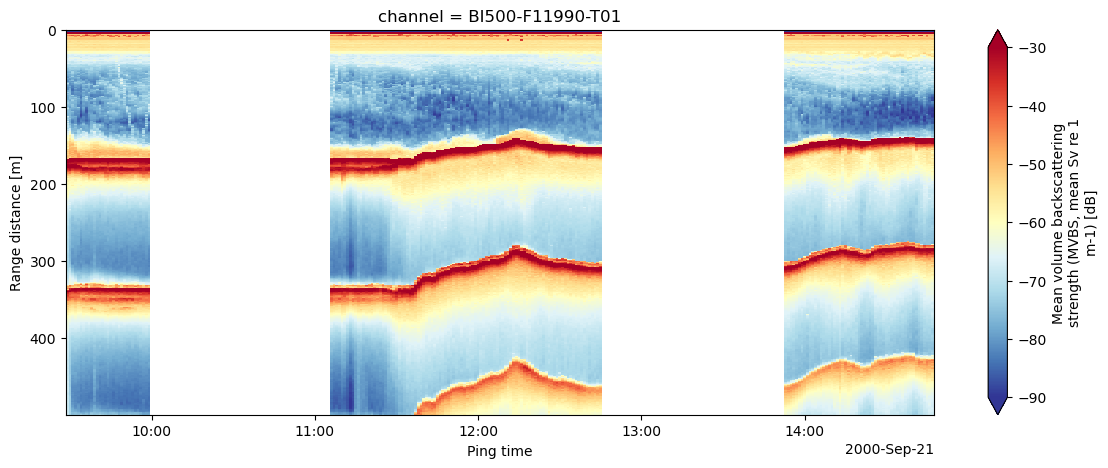

In [20]:
ds_MVBS["Sv"].isel(channel=0).plot(
    x="ping_time",
    yincrease=False,
    vmin=-90,
    vmax=-30,
    cmap="RdYlBu_r",
    figsize=(14, 5),
)


End of notebook.

In [21]:
import sys
from datetime import datetime, timezone

print("Notebook executed:", datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC"))
print("Python:", sys.version.split()[0])
print("echopype:", ep.__version__)
print("xarray:", xr.__version__)
print("numpy:", np.__version__)

Notebook executed: 2026-08-02 19:38:41 UTC
Python: 3.12.13
echopype: 0.11.2.dev183+g02b009a05
xarray: 2026.4.0
numpy: 2.4.4
